In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.read_csv('/content/drive/MyDrive/AML_LAB/anomaly_detection_dataset_500_samples.csv')
df.head()

,Feature_1,Feature_2,Anomaly_Label
0,43.259073,53.716320,0
1,43.815246,43.397717,0
2,46.942411,42.966695,0
3,48.911594,55.493884,0
4,52.575238,69.263657,0


In [8]:
from sklearn.model_selection import train_test_split
X = df[['Feature_1', 'Feature_2']]

y = df['Anomaly_Label']

X_train, X_test, y_train_true, y_test_true = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"Anomalies in Training set: {y_train_true.sum()} ({y_train_true.mean()*100:.2f}%)")
print(f"Anomalies in Test set: {y_test_true.sum()} ({y_test_true.mean()*100:.2f}%)")

Training set size: 350 samples
Test set size: 150 samples
Anomalies in Training set: 21 (6.00%)
Anomalies in Test set: 9 (6.00%)


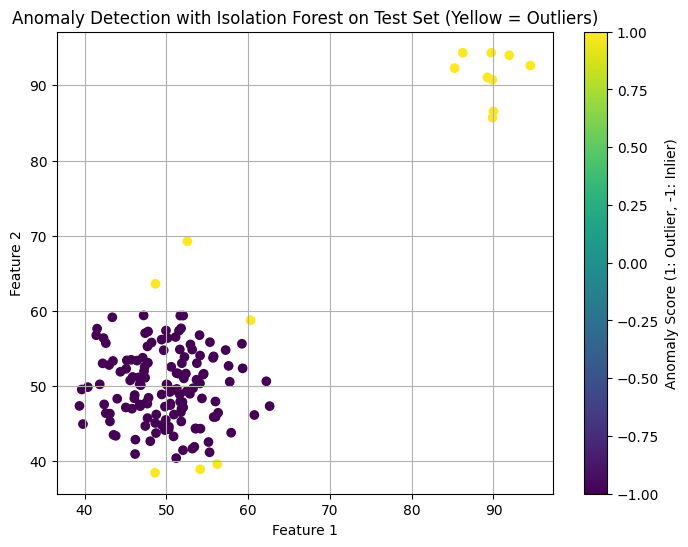

Number of outliers detected by Isolation Forest on Test Set: 15


In [9]:
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_forest.fit(X_train)

y_pred_iso_test = iso_forest.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X_test['Feature_1'], X_test['Feature_2'], c=-y_pred_iso_test, cmap='viridis')
plt.title('Anomaly Detection with Isolation Forest on Test Set (Yellow = Outliers)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Anomaly Score (1: Outlier, -1: Inlier)')
plt.grid(True)
plt.show()

print("Number of outliers detected by Isolation Forest on Test Set:", (y_pred_iso_test == -1).sum())

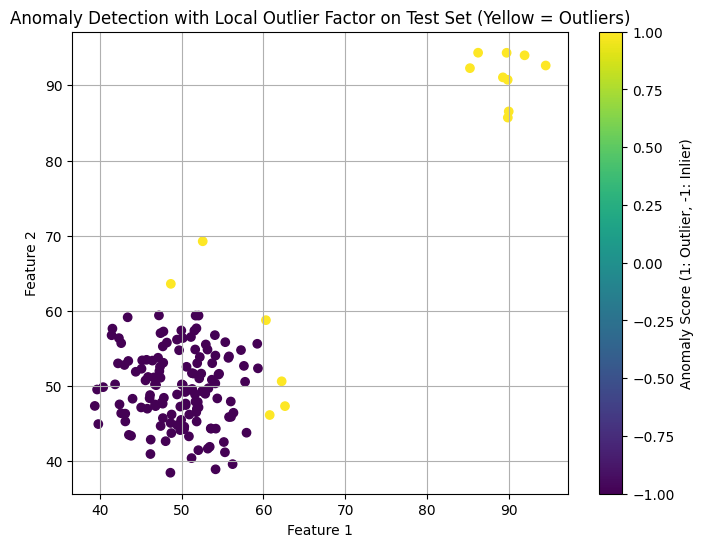

Number of outliers detected by LOF on Test Set: 15


In [10]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
lof.fit(X_train)

y_pred_lof_test = lof.fit_predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X_test['Feature_1'], X_test['Feature_2'], c=-y_pred_lof_test, cmap='viridis')
plt.title('Anomaly Detection with Local Outlier Factor on Test Set (Yellow = Outliers)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Anomaly Score (1: Outlier, -1: Inlier)')
plt.grid(True)
plt.show()

print("Number of outliers detected by LOF on Test Set:", (y_pred_lof_test == -1).sum())

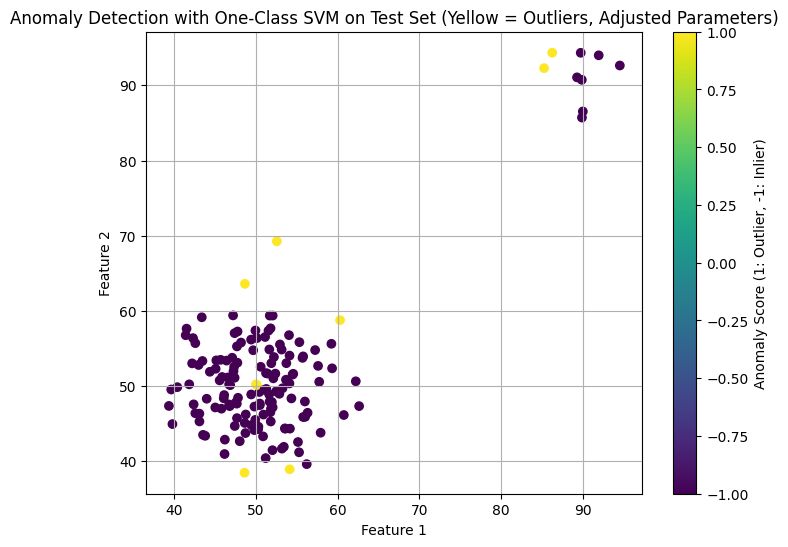

Number of outliers detected by One-Class SVM on Test Set: 9


In [11]:
oc_svm = OneClassSVM(nu=0.05, kernel="rbf", gamma=0.01)
oc_svm.fit(X_train)

y_pred_ocsvm_test = oc_svm.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X_test['Feature_1'], X_test['Feature_2'], c=-y_pred_ocsvm_test, cmap='viridis')
plt.title('Anomaly Detection with One-Class SVM on Test Set (Yellow = Outliers, Adjusted Parameters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Anomaly Score (1: Outlier, -1: Inlier)')
plt.grid(True)
plt.show()

print("Number of outliers detected by One-Class SVM on Test Set:", (y_pred_ocsvm_test == -1).sum())

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score # Use roc_auc_score instead of auc
import numpy as np

y_pred_iso_test_mapped = np.where(y_pred_iso_test == -1, 1, 0)
y_pred_lof_test_mapped = np.where(y_pred_lof_test == -1, 1, 0)
y_pred_ocsvm_test_mapped = np.where(y_pred_ocsvm_test == -1, 1, 0)


iso_scores_test = -iso_forest.decision_function(X_test)
lof_scores_test = -lof.negative_outlier_factor_
ocsvm_scores_test = -oc_svm.decision_function(X_test)


acc_iso = accuracy_score(y_test_true, y_pred_iso_test_mapped)
acc_lof = accuracy_score(y_test_true, y_pred_lof_test_mapped)
acc_ocsvm = accuracy_score(y_test_true, y_pred_ocsvm_test_mapped)


pre_iso = precision_score(y_test_true, y_pred_iso_test_mapped, zero_division=0)
pre_lof = precision_score(y_test_true, y_pred_lof_test_mapped, zero_division=0)
pre_ocsvm = precision_score(y_test_true, y_pred_ocsvm_test_mapped, zero_division=0)

rec_iso = recall_score(y_test_true, y_pred_iso_test_mapped, zero_division=0)
rec_lof = recall_score(y_test_true, y_pred_lof_test_mapped, zero_division=0)
rec_ocsvm = recall_score(y_test_true, y_pred_ocsvm_test_mapped, zero_division=0)

f1_iso = f1_score(y_test_true, y_pred_iso_test_mapped, zero_division=0)
f1_lof = f1_score(y_test_true, y_pred_lof_test_mapped, zero_division=0)
f1_ocsvm = f1_score(y_test_true, y_pred_ocsvm_test_mapped, zero_division=0) # Corrected typo

auc_iso = roc_auc_score(y_test_true, iso_scores_test)
auc_lof = roc_auc_score(y_test_true, lof_scores_test)
auc_ocsvm = roc_auc_score(y_test_true, ocsvm_scores_test)

In [13]:
Model = ['ISO', 'LOF', 'OCSVM']
Accuracy = [acc_iso, acc_lof, acc_ocsvm]
Recall = [rec_iso, rec_lof, rec_ocsvm]
Precision = [pre_iso, pre_lof, pre_ocsvm]
F1_Score = [f1_iso, f1_lof, f1_ocsvm]
Auc = [auc_iso, auc_lof, auc_ocsvm]

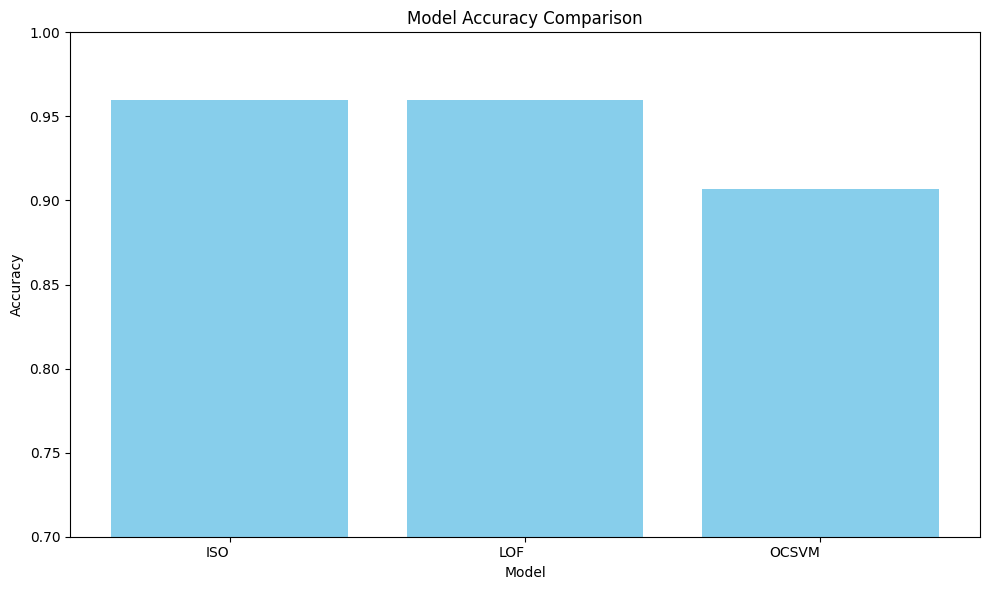

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, Accuracy, color='skyblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

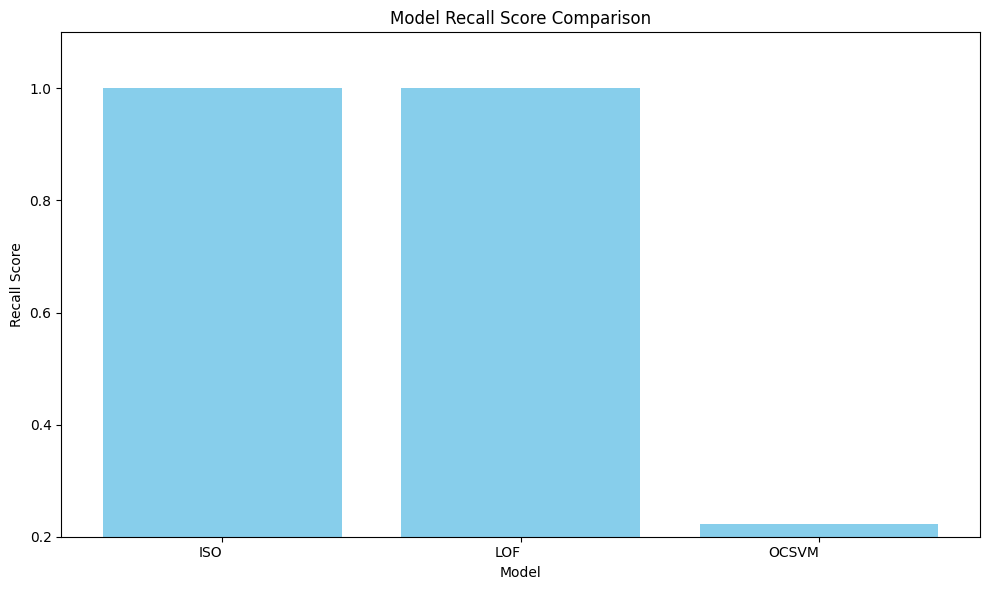

In [15]:
plt.figure(figsize=(10, 6))
plt.bar(Model, Recall, color='skyblue')
plt.title('Model Recall Score Comparison')
plt.ylabel('Recall Score')
plt.xlabel('Model')
plt.ylim(0.2, 1.1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

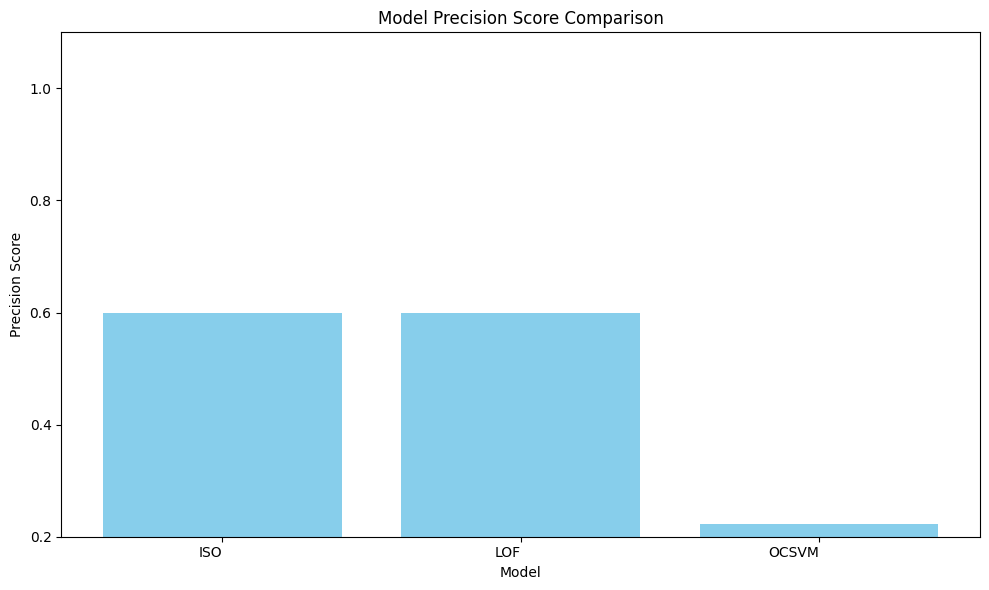

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(Model, Precision, color='skyblue')
plt.title('Model Precision Score Comparison')
plt.ylabel('Precision Score')
plt.xlabel('Model')
plt.ylim(0.2, 1.1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

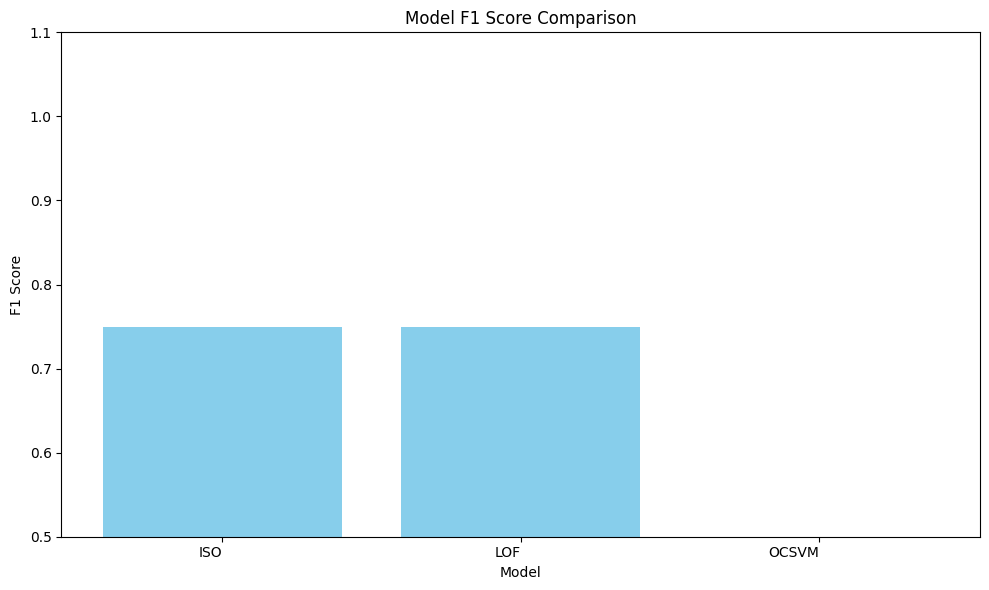

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(Model, F1_Score, color='skyblue')
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.ylim(0.5, 1.1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

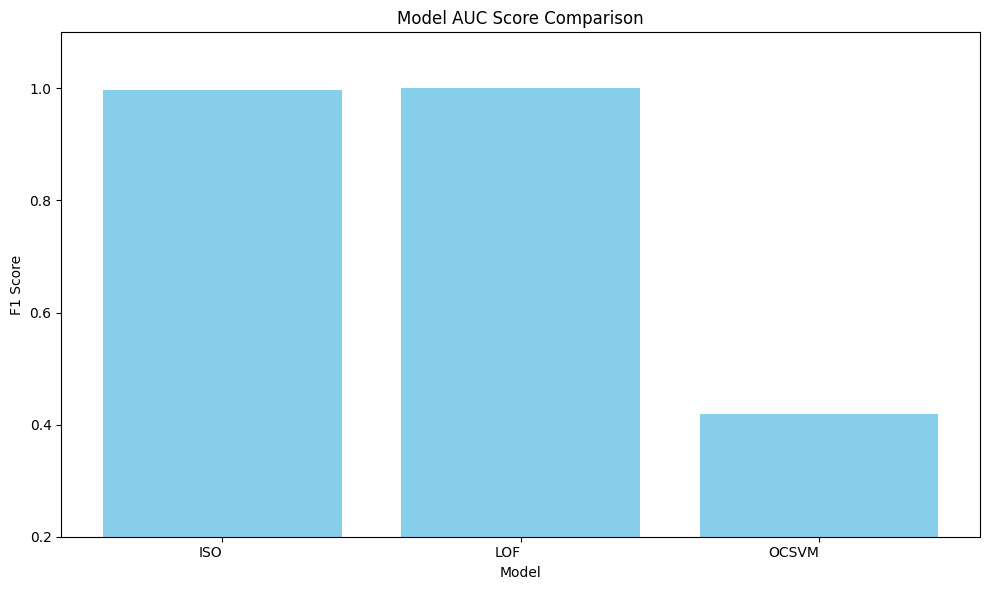

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(Model, Auc, color='skyblue')
plt.title('Model AUC Score Comparison')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.ylim(0.2, 1.1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

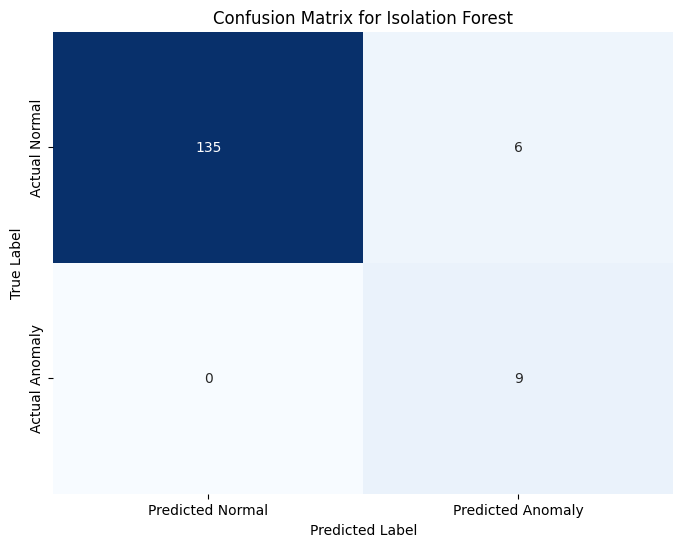

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test_true, y_pred_iso_test_mapped, labels=[0, 1])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Confusion Matrix for Isolation Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

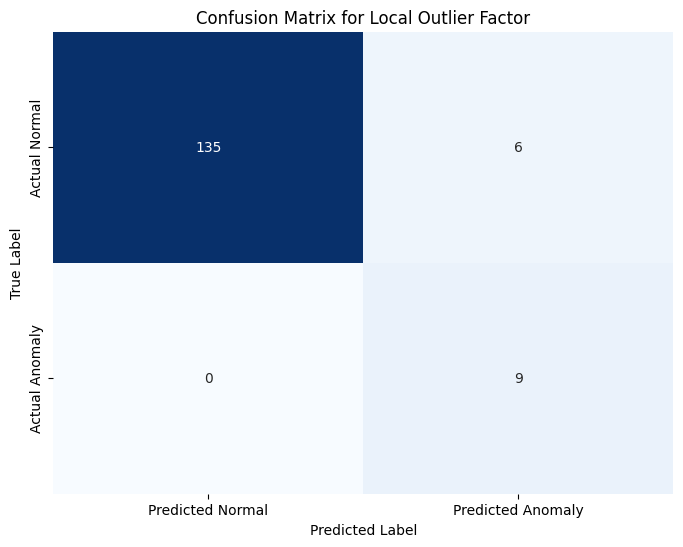

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test_true, y_pred_lof_test_mapped, labels=[0, 1])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Confusion Matrix for Local Outlier Factor')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

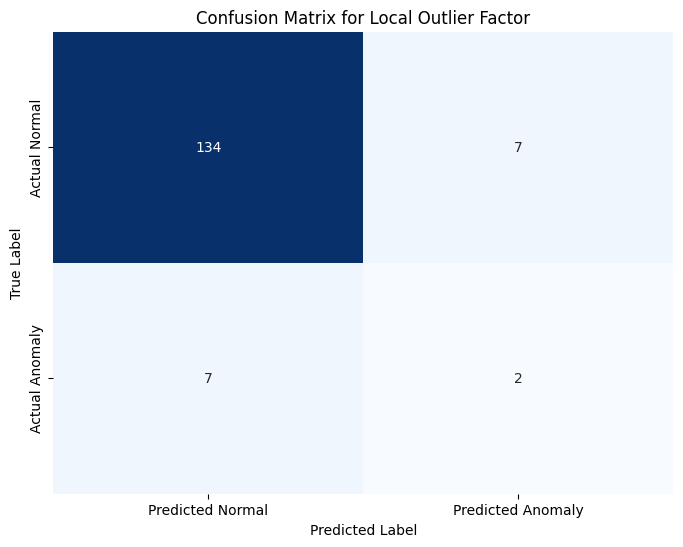

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test_true, y_pred_ocsvm_test_mapped, labels=[0, 1])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Confusion Matrix for Local Outlier Factor')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()